# EDA for Factors Associated with Survival Rates on the Titanic Disaster
**Dataset**: Titanic Dataset from Kaggle  
**Link**: https://www.kaggle.com/datasets/yasserh/titanic-dataset  
**Goal**: Understand what factors influenced survival on the Titanic  
**Author**: Isaac Jun 


In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline

## 1. Load & Inspect
For this section, we will inspect the dataset to decide what to do, such as data cleaning, visualizing, and analyzing. 

In [2]:
filepath = 'Titanic-Dataset.csv'
my_data = pd.read_csv(filepath)
my_data


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
my_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
my_data.shape

(891, 12)

In [5]:
my_data.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [6]:
my_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Conclusion
The data set consists of 12 columns:

**PassengerId** : passenger Id  
**Survived** : 1 for survived and 0 for dead  
**Pclass** : ticket class from first class being 1 to third class being 3  
**Name** : name of a passenger  
**Sex** : sexuality of a passenger  
**Age** : age of a passenger  
**SibSp** : number of the siblings or spouse aboard the Titanic  
**Parch** : number of the parents or children aboard the Titanic  
**Ticket** : ticket number  
**Fare** : passenger fare  
**Cabin** : cabin number  
**Embarked** : Port of Embarkation — C = Cherbourg, Q = Queenstown, S = Southampton  

Three columns require cleaning: **Age** (177 missing, 19.9%), **Cabin** (687 missing, 77.1%), and **Embarked** (2 missing, 0.2%).

## 2. Data Cleaning
From inspection, we detached a few data points that need to be cleaned: age, embarked, and cabin. This section will describe a way to deal with each data point. 


### Cabin
Cabin column has 687 missing values, which is about 77% of the total data. Since more than 50% of the data is missing, deleting the whole column seems a reasonable choice. 

In [7]:
my_data = my_data.drop(columns = 'Cabin')

### Age
Age column has 177 missing values (19.9% of total). Since the missingness appears random, we fill with the **median** rather than the mean — the median is more robust to outliers in the age distribution.

In [8]:
my_data['Age'] = my_data['Age'].fillna(my_data['Age'].median())

### Embarked
Embarked has only 2 missing values — likely a simple data entry error. We fill with the **mode** (most frequent port), which is Southampton (S).

In [9]:
my_data['Embarked'] = my_data['Embarked'].fillna(my_data['Embarked'].mode()[0])

### Dropping the Unnecessary Columns
Before moving on to visualization and analysis, we will delete unnecessary data columns:  PassengerId, Name, and Ticket. 

In [10]:
my_data = my_data.drop(columns = ['PassengerId', 'Name', 'Ticket'])

### Conclusion
We filled out missing values for Age and Embarked and deleted unnecessary and sparse columns, such as Cabin, PassengerID, Name, and Ticket. The data table below shows that we successfully cleansed our data: no missing or unnecessary values. 

In [11]:
print(my_data.isnull().sum())
my_data.head()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## 3. Visualization & Analysis
In this section, we will visualize the data that will be analyzed. We will visualize each column by comparing it with the Survived columns to determine whether each column's data is associated with survival rates. Each data point will be visualized with different plots based on its data types. We will also analyze them with the different methods that suit each situation. The logic behind choosing a plot and method will be described in each data section. 

### 3.1 Survival Rates
To begin with, we will first analyze the overall survival rate of every single passenger. This rate can be later used to test whether each data point is statistically significant. 

Text(0.5, 1.0, 'Number of Survived')

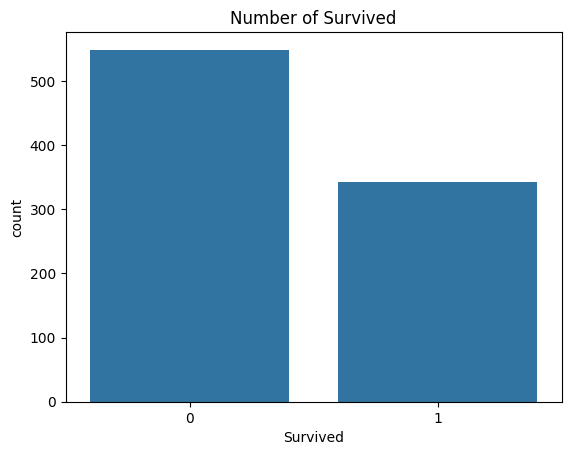

In [12]:
sns.countplot(my_data, x = 'Survived')
plt.title('Number of Survived')

In [13]:
survived = len(my_data[my_data['Survived'] == 1])
dead = len(my_data[my_data['Survived'] == 0])
SUR_RATE_OVERALL = survived/(survived+dead)
DEAD_RATE_OVERALL = dead/(survived+dead)
print("Survived: ", survived, " / Dead: ", dead)
print(f"{SUR_RATE_OVERALL * 100:.2f}% survived")
print(f"{DEAD_RATE_OVERALL * 100:.2f}% dead")

Survived:  342  / Dead:  549
38.38% survived
61.62% dead


#### Conclusion
We can conclude that the survival rate was 38.38%. This rate will be used in binomail test for each data. 

### 3.2 Sexuality  
**Null Hypothesis**: The sexuality of the passenger is not associated with the survival rates.  

We can first visualize the data with countplot and examine whether the male and female survival rates were different. Then, we can use statistical testing (chi-square test) to analyze whether male and female survival rates were significantly different. We can also finally check using the binomial test using overall survival rate to test whether each value is significantly different from the overall survival rate. 


<Axes: xlabel='Sex', ylabel='count'>

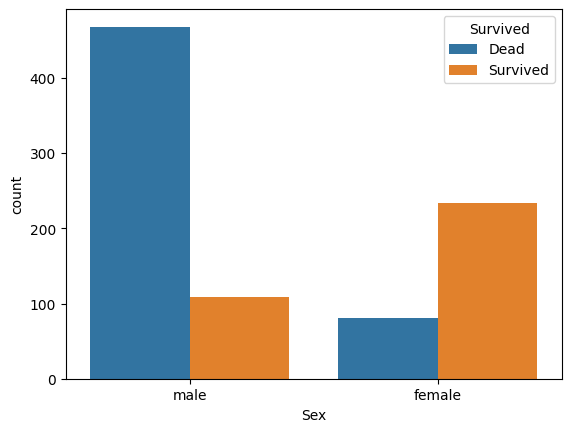

In [14]:
f2 , ax1 = plt.subplots(1, 1, sharex=True)

sns.countplot(my_data.replace(to_replace=[1,0], value=['Survived','Dead']), x = 'Sex', hue='Survived', ax = ax1)

In [15]:
sex_sur = my_data.groupby('Sex')['Survived'].value_counts()
ma_sur  = sex_sur['male'][1]
ma_dead = sex_sur['male'][0]
fe_sur  = sex_sur['female'][1]
fe_dead = sex_sur['female'][0]
table = np.array([[ma_sur, ma_dead],[fe_sur,fe_dead]])
chi2, p, dof, expected = stats.chi2_contingency(table)
print(f"Chi2: {chi2:.4f}, p-value: {p:.6f}, df: {dof}")

result = stats.binomtest(ma_sur, n = ma_sur+ma_dead, p=SUR_RATE_OVERALL)
print(f"Men p-value: {result.pvalue:.6f}")
result = stats.binomtest(fe_sur, n = fe_sur+fe_dead, p=SUR_RATE_OVERALL)
print(f"Women 2 p-value: {result.pvalue:.6f}")

print(f"Man's Survival Rate: {ma_sur / (ma_sur+ma_dead)}")
print(f"Woman's Survival Rate: {fe_sur / (fe_sur+fe_dead)}")

Chi2: 260.7170, p-value: 0.000000, df: 1
Men p-value: 0.000000
Women 2 p-value: 0.000000
Man's Survival Rate: 0.18890814558058924
Woman's Survival Rate: 0.7420382165605095


#### Conclusion
We verified our result through statistical testing. The chi-square test between men and women had a p < 0.05, and the binomial test for each sexuality also had a p < 0.05

To conclude, man’s survival rate was about 19% while woman’s was about 74%. The woman was 3.9 times more likely to survive compared to a man. 

### 3.3 Pclass
**Null Hypothesis**: The class of passengers is not associated with the survival rates.  

Similar logic with sexuality can be applied to Pclass: the only difference is that Pclass has 3 values (1,2,3) while sexuality only has two. Hence, we should add more chi-square tests to compare each of the values separately, such as class 1 and class 2, class 2 and class 3, and class 1 and class 3. 

<Axes: xlabel='Pclass', ylabel='count'>

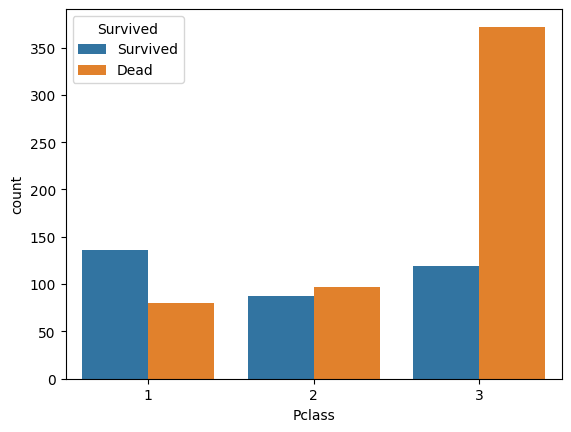

In [16]:
f2 , ax1 = plt.subplots(1, 1, sharex=True)

sns.countplot(data=my_data, x = 'Pclass', hue=my_data['Survived'].map({1: 'Survived', 0: 'Dead'}), ax = ax1)

In [17]:
class_sur = my_data.groupby('Pclass')['Survived'].value_counts()
one_sur  = class_sur[1][1]
one_dead = class_sur[1][0]
two_sur  = class_sur[2][1]
two_dead = class_sur[2][0]
three_sur = class_sur[3][1]
three_dead = class_sur[3][0]

table = np.array([[one_sur, one_dead],[two_sur,two_dead],[three_sur,three_dead]])
chi2, p, dof, expected = stats.chi2_contingency(table)
print(f"Chi2: {chi2:.4f}, p-value: {p:.6f}, df: {dof}")

table = np.array([[one_sur, one_dead],[two_sur,two_dead]])
chi2, p, dof, expected = stats.chi2_contingency(table)
print('Compare group 1 and 2')
print(f"Chi2: {chi2:.4f}, p-value: {p:.6f}, df: {dof}")

table = np.array([[three_sur,three_dead],[two_sur,two_dead]])
chi2, p, dof, expected = stats.chi2_contingency(table)
print('Compare group 2 and 3')
print(f"Chi2: {chi2:.4f}, p-value: {p:.6f}, df: {dof}")

table = np.array([[three_sur,three_dead],[one_sur, one_dead]])
chi2, p, dof, expected = stats.chi2_contingency(table)
print('Compare group 1 and 3')
print(f"Chi2: {chi2:.4f}, p-value: {p:.6f}, df: {dof}")



Chi2: 102.8890, p-value: 0.000000, df: 2
Compare group 1 and 2
Chi2: 9.2775, p-value: 0.002320, df: 1
Compare group 2 and 3
Chi2: 32.4469, p-value: 0.000000, df: 1
Compare group 1 and 3
Chi2: 95.8935, p-value: 0.000000, df: 1


In [18]:
result = stats.binomtest(one_sur, n = one_sur+one_dead, p=SUR_RATE_OVERALL)
print(f"Group 1 p-value: {result.pvalue:.6f}")
result = stats.binomtest(two_sur, n = two_sur+two_dead, p=SUR_RATE_OVERALL)
print(f"Group 2 p-value: {result.pvalue:.6f}")
result = stats.binomtest(three_sur, n = three_sur+three_dead, p=SUR_RATE_OVERALL)
print(f"Group 3 p-value: {result.pvalue:.6f}")

# print(f"Number of Class 1: {}, Class 2: {}, Class 3: {}")
print(f"Rates for each class\n1: {one_sur/(one_sur+one_dead)}, 2: {two_sur/(two_sur+two_dead)}, 3: {three_sur/(three_sur+three_dead)}")
print(f"Times compared to overall for each class\n1: {(one_sur/(one_sur+one_dead))/SUR_RATE_OVERALL}, 2: {(two_sur/(two_sur+two_dead))/SUR_RATE_OVERALL}, 3: {(three_sur/(three_sur+three_dead))/SUR_RATE_OVERALL}")

Group 1 p-value: 0.000000
Group 2 p-value: 0.015109
Group 3 p-value: 0.000000
Rates for each class
1: 0.6296296296296297, 2: 0.47282608695652173, 3: 0.24236252545824846
Times compared to overall for each class
1: 1.6403508771929827, 2: 1.2318363844393594, 3: 0.6314181584307


#### Conclusion
Every chi-square test resulted in p < 0.05; hence, every class had different survival rates. Every binomial test resulted in p < 0.05; hence, every class had difference distribution compared to the overall.  

To conclude, class 1 was 1.64 times more likely to survive than overall, 1.23 times for class 2, and 0.63 times for class 3. The more upper-class you were, the more likely you were to survive. 


### 3.4 Embarked
**Null Hypothesis**: The embarkation port of passengers is not associated with the survival rates.  

Same logic with Pclass since data types and number of values are the same. 

<Axes: xlabel='Embarked', ylabel='count'>

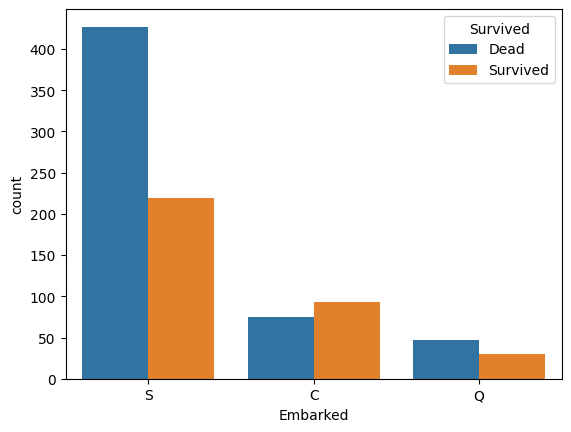

In [19]:
f2 , ax1 = plt.subplots(1, 1, sharex=True)

sns.countplot(data=my_data, x = 'Embarked', hue=my_data['Survived'].map({1: 'Survived', 0: 'Dead'}), ax = ax1)

In [20]:
class_sur = my_data.groupby('Embarked')['Survived'].value_counts()
s_sur  = class_sur['S'][1]
s_dead = class_sur['S'][0]
c_sur  = class_sur['C'][1]
c_dead = class_sur['C'][0]
q_sur = class_sur['Q'][1]
q_dead = class_sur['Q'][0]

table = np.array([[s_sur, s_dead],[c_sur,c_dead],[q_sur,q_dead]])
chi2, p, dof, expected = stats.chi2_contingency(table)
print(f"Chi2: {chi2:.4f}, p-value: {p:.6f}, df: {dof}")

table = np.array([[s_sur, s_dead],[c_sur,c_dead]])
chi2, p, dof, expected = stats.chi2_contingency(table)
print('Compare group S and C')
print(f"Chi2: {chi2:.4f}, p-value: {p:.6f}, df: {dof}")

table = np.array([[q_sur,q_dead],[c_sur,c_dead]])
chi2, p, dof, expected = stats.chi2_contingency(table)
print('Compare group C and Q')
print(f"Chi2: {chi2:.4f}, p-value: {p:.6f}, df: {dof}")

table = np.array([[q_sur,q_dead],[s_sur, s_dead]])
chi2, p, dof, expected = stats.chi2_contingency(table)
print('Compare group S and Q')
print(f"Chi2: {chi2:.4f}, p-value: {p:.6f}, df: {dof}")



Chi2: 25.9645, p-value: 0.000002, df: 2
Compare group S and C
Chi2: 25.0668, p-value: 0.000001, df: 1
Compare group C and Q
Chi2: 5.0409, p-value: 0.024755, df: 1
Compare group S and Q
Chi2: 0.5722, p-value: 0.449394, df: 1


In [21]:
result = stats.binomtest(s_sur, n = s_sur+s_dead, p=SUR_RATE_OVERALL)
print(f"Group S p-value: {result.pvalue:.6f}")
result = stats.binomtest(c_sur, n = c_sur+c_dead, p=SUR_RATE_OVERALL)
print(f"Group C p-value: {result.pvalue:.6f}")
result = stats.binomtest(q_sur, n = q_sur+q_dead, p=SUR_RATE_OVERALL)
print(f"Group Q p-value: {result.pvalue:.6f}")

print(f"Rates for each class\nS: {s_sur/(s_sur+s_dead)}, C: {c_sur/(c_sur+c_dead)}, Q: {q_sur/(q_sur+q_dead)}")
print(f"Times compared to overall for each class\nS: {(s_sur/(s_sur+s_dead))/SUR_RATE_OVERALL}, C: {(c_sur/(c_sur+c_dead))/SUR_RATE_OVERALL}, Q: {(q_sur/(q_sur+q_dead))/SUR_RATE_OVERALL}")

Group S p-value: 0.018968
Group C p-value: 0.000011
Group Q p-value: 0.907293
Rates for each class
S: 0.33900928792569657, C: 0.5535714285714286, Q: 0.38961038961038963
Times compared to overall for each class
S: 0.8832084080169463, C: 1.442199248120301, Q: 1.0150375939849625


#### Conclusion
Chi-square shows overall embarkation port is significantly associated with survival (p < 0.05). Pairwise comparison shows S and C are significantly different, as are C and Q. However S and Q are not significantly different from each other.

Binomial test against overall rate shows:
- C (55.4%): significantly above average — 1.44x more likely to survive
- S (33.9%): significantly below average — 0.88x the average rate  
- Q (38.9%): not significantly different from overall — sits right at average

Note: Q's non-significance likely reflects its small sample size (77 passengers) rather than a true absence of effect. 

To conclude, being ported to C increased the likelihood of surviving. 

### 3.5 Number of Siblings/Spouses (SibSp) and Parents/Children (Parch)
**Null Hypothesis**: The number of family members aboard is not associated with survival rates.

SibSp and Parch both measure family presence so we analyze them together. We use **violin plots** which show the full distribution shape — better than boxplots for these heavily skewed counts. We then apply the **Mann-Whitney U test** since both distributions are non-normal.

[Text(0, 0, 'Dead'), Text(1, 0, 'Survived')]

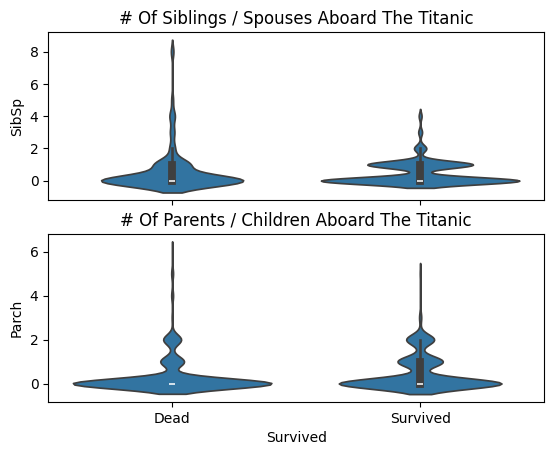

In [22]:
f2 , (ax1, ax3) = plt.subplots(2, 1, sharex=True)
ax1.set_title('# of siblings / spouses aboard the Titanic'.title())
sns.violinplot(data=my_data, x = 'Survived', y = 'SibSp', ax = ax1)

ax3.set_title('# of parents / children aboard the Titanic'.title())
sns.violinplot(data=my_data, x = 'Survived', y = 'Parch', ax = ax3)
ax3.set_xticks([0,1])
ax3.set_xticklabels(['Dead', 'Survived'])

In [23]:
sib_dead = my_data.loc[my_data['Survived'] == 0, 'SibSp']
sib_sur = my_data.loc[my_data['Survived'] == 1, 'SibSp']
stat, p = stats.mannwhitneyu(sib_dead, sib_sur)
print('# of siblings / spouses aboard the Titanic')
print(f"U-statistics: {stat}, P-Value: {p}")
print("Mean for Survived:" , sib_sur.mean(), ", Mean for Dead: ", sib_dead.mean())

par_dead = my_data.loc[my_data['Survived'] == 0, 'Parch']
par_sur = my_data.loc[my_data['Survived'] == 1, 'Parch']
stat, p = stats.mannwhitneyu(par_dead, par_sur)

print('# of parents / children aboard the Titanic')
print(f"U-statistics: {stat}, P-Value: {p}")
print("Mean for Survived:" , par_sur.mean(), ", Mean for Dead: ", par_dead.mean())



# of siblings / spouses aboard the Titanic
U-statistics: 85775.0, P-Value: 0.008016684059168793
Mean for Survived: 0.47368421052631576 , Mean for Dead:  0.5537340619307832
# of parents / children aboard the Titanic
U-statistics: 82385.0, P-Value: 3.712490908378456e-05
Mean for Survived: 0.4649122807017544 , Mean for Dead:  0.3296903460837887


Based on the Mann-Whitney U test (p < 0.05 for both), family structure shows a statistically significant association with survival.

- **SibSp**: Survivors had a slightly lower mean (0.47) than those who died (0.55). More siblings/spouses aboard was mildly associated with lower survival.
- **Parch**: Survivors had a higher mean (0.46) than those who died (0.33). Traveling with parents or children was mildly associated with higher survival — consistent with families being prioritized during evacuation.

The effect sizes are small — family structure was a weaker predictor than sex or class.

### 3.6 Age
**Null Hypothesis**: Age is not associated with survival rates.

Age is a continuous numerical variable. We visualize its distribution for survivors and non-survivors separately using histplots. We apply **Welch's t-test** (equal_var=False) since we cannot assume equal variance between the two groups.

Text(0.5, 1.0, 'Dead')

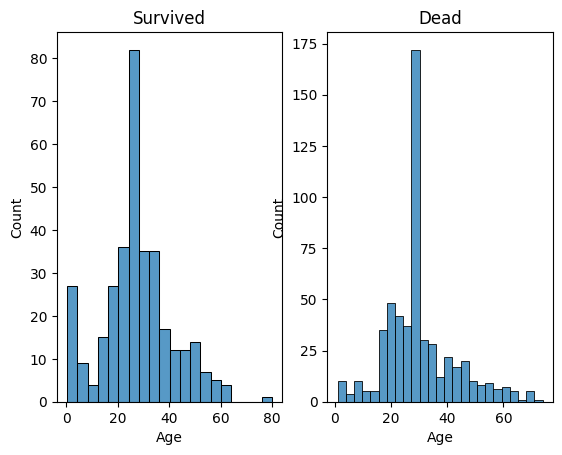

In [24]:
f1, axes = plt.subplots(1,2)
sns.histplot(data = my_data.loc[my_data['Survived'] == 1], x = 'Age', ax=axes[0])
axes[0].set_title("Survived")
sns.histplot(data = my_data.loc[my_data['Survived'] == 0], x = 'Age', ax=axes[1])
axes[1].set_title("Dead")

In [25]:
survived_age = my_data.loc[my_data['Survived'] == 1,'Age']
dead_age = my_data.loc[my_data['Survived'] == 0,'Age']

print(f"Mean Age for Survived: {survived_age.mean()}, For Dead: {dead_age.mean()}")
statistics, p = stats.ttest_ind(survived_age,dead_age, equal_var=False)
print(f'T-Value: {statistics}, P-Value: {p}')

Mean Age for Survived: 28.29143274853801, For Dead: 30.028233151183972
T-Value: -1.8966053920256696, P-Value: 0.0583091599777575


The Welch t-test gives p = 0.058 — just above the 0.05 threshold. We cannot reject the null hypothesis: **age overall is not a statistically significant predictor of survival**.

However two nuances apply:
1. The result is borderline — p = 0.058 is very close to significant
2. The histogram suggests **children under 10 had noticeably higher survival rates**, a pattern the t-test misses by comparing means

This is consistent with the 'women and children first' protocol — children were likely prioritized despite the aggregate result being non-significant.

### 3.7 Fare
**Null Hypothesis**: Ticket fare is not associated with survival rates.

Fare is continuous but heavily right-skewed — a small number of passengers paid very high fares. We use histplots to visualize distributions and the **Mann-Whitney U test** instead of a t-test, which is more appropriate for non-normal distributions.

Text(0.5, 1.0, 'Dead')

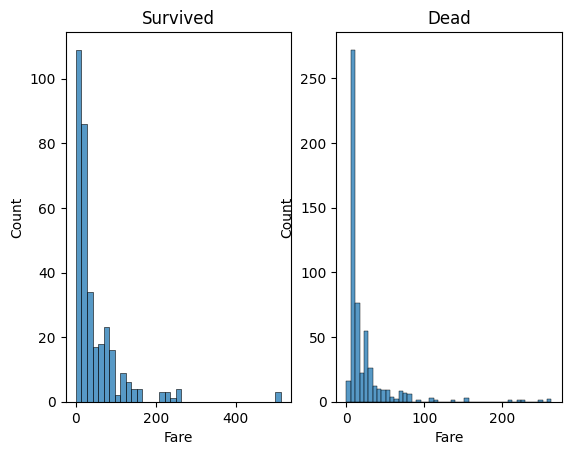

In [26]:
f1, axes = plt.subplots(1,2)
sns.histplot(data = my_data.loc[my_data['Survived'] == 1], x = 'Fare', ax=axes[0])
axes[0].set_title("Survived")
sns.histplot(data = my_data.loc[my_data['Survived'] == 0], x = 'Fare', ax=axes[1])
axes[1].set_title("Dead")

In [27]:
survived_fare = my_data.loc[my_data['Survived'] == 1,'Fare']
dead_fare = my_data.loc[my_data['Survived'] == 0,'Fare']

print(f"Mean Fare for Survived: {survived_fare.mean()}, For Dead: {dead_fare.mean()}")
statistics, p = stats.mannwhitneyu(survived_fare,dead_fare)
print(f'T-Value: {statistics}, P-Value: {p}')

Mean Fare for Survived: 48.39540760233918, For Dead: 22.117886885245902
T-Value: 129951.5, P-Value: 4.553477179250237e-22


The Mann-Whitney U test confirms a statistically significant association between fare and survival (p < 0.05). Survivors paid a substantially higher mean fare ($48.40) compared to those who died ($22.12) — more than double.

This is likely a **proxy effect**: higher fares correspond to higher passenger class, which provided better cabin locations and lifeboat access. Fare and Pclass together tell the same story — wealth determined survival chances on the Titanic.

### 3.8 Correlation Heatmap
**Hypothesis**: Fare and Pclass will show the strongest correlations with Survived among numerical features, and Fare and Pclass will be strongly negatively correlated with each other.

A **heatmap** visualizes pairwise Pearson correlations between all numerical features, giving an overall picture of which features move together and which are most associated with survival.

<Axes: >

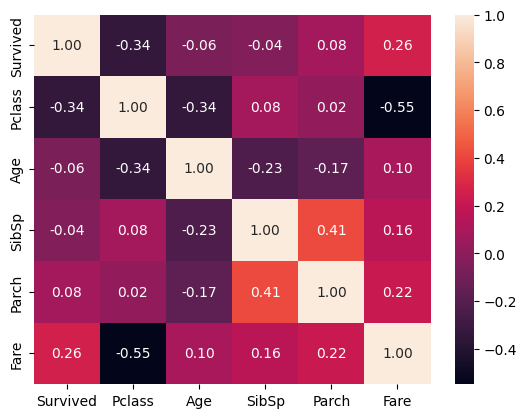

In [28]:
sns.heatmap(my_data.select_dtypes(include='number').corr(), annot = True, fmt = '.2f')

#### Conclusion
The heatmap confirms the patterns found in individual analyses:

- **Fare** (0.26) and **Pclass** (-0.34) show the strongest correlations with Survived among numerical features
- **Pclass and Fare** are strongly negatively correlated (-0.55): higher class passengers paid higher fares
- **SibSp and Parch** show weak positive correlation (0.41) — both measure family presence
- **Age** shows near-zero correlation with Survived (0.07), consistent with our non-significant t-test

Wealth-related features (Pclass, Fare) were the dominant numerical predictors of survival.

## 4. Key Insights

### Insight 1: Survival was the minority outcome
Only **38.4%** of the 891 passengers survived. Understanding which factors separated survivors from non-survivors is the core question of this analysis.

### Insight 2: Sex was the single strongest predictor
Women survived at **74%** vs only **19%** for men — women were **3.9x more likely** to survive. Both groups were significantly different from the overall rate (p < 0.05). This directly reflects the 'women and children first' evacuation protocol.

### Insight 3: Passenger class determined lifeboat access
Survival dropped sharply across classes: **1st (63%) → 2nd (47%) → 3rd (24%)**. Every pairwise comparison was statistically significant (p < 0.05). First class passengers were **1.64x** more likely to survive than average; 3rd class were only **0.63x** — wealth and social class directly determined survival.

### Insight 4: Fare was a proxy for class and therefore survival
Survivors paid more than double the fare of non-survivors ($48.40 vs $22.12, p < 0.05). Since Fare and Pclass are strongly correlated (-0.55), economic status — measured by either variable — was a dominant survival factor.

### Insight 5: Age was not a significant predictor overall, but children were likely prioritized
The t-test for age was borderline non-significant (p = 0.058). However the histogram suggests children under 10 had higher survival rates, consistent with the 'women and children first' protocol. This is a reminder that statistical tests and visualizations must be interpreted together — a non-significant mean comparison can still hide meaningful subgroup patterns.

---
## 5. Limitations
- **Age imputation**: 177 values filled with median may slightly weaken age-related findings
- **Cabin dropped**: Missingness itself may have been informative — passengers without cabin records were likely 3rd class
- **Observational data**: All findings are associational, not causal
- **Small subgroups**: Embarked group Q had only 77 passengers, reducing statistical power